# **StarSight**
## *AI-Enabled Detection of Exoplanets from Noisy Astronomical Light Curves*

### **Milestone 1: Project Setup and Data Acquisition**

**Objective:**
Initialize the StarSight folders and download a small development dataset of Kepler space observations for confirmed exoplanet hosts. Programmatically inspect observation metadata directly from Lightkurve objects and visualize raw light curves.

### **2. Install Packages**
Detect the running environment (Google Colab vs. Local) and install missing packages if running on Colab.

In [9]:
import sys
from pathlib import Path

# Resolve repository root
current_path = Path.cwd()
repo_root = None

if 'google.colab' in sys.modules:
    print("Running in Google Colab. Installing dependencies...")
    # Install dependencies programmatically in Jupyter environment
    get_ipython().system('pip install -q lightkurve astropy tqdm pandas numpy matplotlib scipy torch')
    
    # Auto-mount Google Drive first to resolve path checks
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception as e:
        print(f"Warning: Could not automatically mount Google Drive: {e}")
        
    # In Colab, check if repo is cloned, if not clone it automatically
    if not Path('/content/StarSight/src').exists():
        print("StarSight source code not found in /content. Cloning repository from GitHub...")
        get_ipython().system('git clone https://github.com/Suryansh-FSD/StarSight.git /content/StarSight')
        
    # Set repository root
    if Path('/content/StarSight/src').exists():
        repo_root = Path('/content/StarSight')
    elif Path('/content/drive/MyDrive/StarSight/src').exists():
        repo_root = Path('/content/drive/MyDrive/StarSight')
    else:
        repo_root = Path('/content/drive/MyDrive/StarSight')
else:
    # Local environment (search upwards for the directory containing 'src')
    for p in [current_path, current_path.parent, current_path.parent.parent]:
        if (p / 'src').exists():
            repo_root = p
            break

if repo_root is None:
    repo_root = current_path

src_path = str(repo_root.resolve())
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from src.utils.colab import print_environment_summary
print_environment_summary()

Running in Google Colab. Installing dependencies...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


ModuleNotFoundError: No module named 'src'

### **3. Imports**
Import standard library and scientific libraries for data management, plotting, and file copying.

In [ ]:
import logging
import os
import shutil
import socket
import sys
from pathlib import Path
from typing import Dict, List, Optional

import astropy.io.fits as fits
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Set a global socket timeout to prevent network operations from hanging indefinitely
socket.setdefaulttimeout(30)

/Users/suryanshdixit/Desktop/StarSight/.venv/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(
/Users/suryanshdixit/Desktop/StarSight/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **4. Configuration & Constants**
Configure relative paths, configurable target limits, and download parameters.

In [ ]:
# Resolve the project root path relative to this notebook
notebook_dir = Path.cwd()
PROJECT_ROOT = notebook_dir.parent if notebook_dir.name == "notebooks" else notebook_dir

# Target list containing confirmed exoplanets
DEVELOPMENT_TARGETS = [
    "Kepler-10",
    "Kepler-22",
    "Kepler-90",
    "Kepler-186",
    "Kepler-452",
    "Kepler-62",
    "Kepler-7",
    "Kepler-8"
]

# Configurable Constants for custom run options
MAX_TARGETS = 8
SAVE_PLOTS = True
VERBOSE = True
KEPLER_QUARTER = None  # None: download first available; integer: download specific quarter

### **5. Logging Configuration**
Initialize logging based on the configured verbosity setting.

In [ ]:
log_level = logging.INFO if VERBOSE else logging.WARNING
logging.basicConfig(
    level=log_level,
    format="%(asctime)s [%(levelname)s] %(name)s - %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)]
)
logger = logging.getLogger("StarSight.Acquisition")

### **6. Helper Functions**
Define modular, documented helper functions to handle folders, downloads, metadata checks, and plotting.

In [ ]:
def create_project_directories(root_dir: Path) -> Dict[str, Path]:
    """
    Create the data folders (raw, processed) and results directory if they do not exist.

    Args:
        root_dir: Path pointing to the root of the project.

    Returns:
        Dict[str, Path]: Map of directory aliases to absolute paths.
    """
    dirs = {
        "raw": root_dir / "data" / "raw",
        "processed": root_dir / "data" / "processed",
        "results": root_dir / "results"
    }
    for name, path in dirs.items():
        path.mkdir(parents=True, exist_ok=True)
        logger.info(f"Configured directory {name}: {path.resolve()}")
    return dirs

def download_light_curve(target: str, quarter: Optional[int] = None) -> Optional[lk.LightCurve]:
    """
    Search for and download a Kepler long-cadence light curve for a target host star.

    Args:
        target: Name of the Kepler target (e.g., 'Kepler-10').
        quarter: The Kepler mission observation quarter. If None, retrieves first available.

    Returns:
        Optional[lk.LightCurve]: The downloaded LightCurve object, or None if download fails.
    """
    try:
        logger.info(f"Querying MAST archive for target: {target} (Quarter: {quarter or 'first available'}, Cadence: Long)")
        search_result = lk.search_lightcurve(
            target,
            author="Kepler",
            quarter=quarter,
            cadence="long"
        )

        # Fallback query if specific quarter is not found
        if len(search_result) == 0 and quarter is not None:
            logger.warning(f"Target {target} not found in Quarter {quarter}. Querying generally.")
            search_result = lk.search_lightcurve(target, author="Kepler", cadence="long")

        if len(search_result) == 0:
            logger.error(f"No long-cadence light curves found for target {target}")
            return None

        # Download the first result
        logger.info(f"Downloading observations for {target}...")
        lc = search_result[0].download()
        return lc
    except Exception as e:
        logger.error(f"Error downloading target {target}: {str(e)}")
        return None

def save_fits(lc: lk.LightCurve, filepath: Path) -> None:
    """
    Save a downloaded LightCurve object locally as a raw FITS file.
    We copy the original cached FITS file to preserve all official headers and columns.

    Args:
        lc: The downloaded LightCurve instance.
        filepath: Destination file path for the output FITS file.
    """
    try:
        if hasattr(lc, "filename") and lc.filename:
            shutil.copy(lc.filename, filepath)
            logger.info(f"Successfully saved raw FITS file to: {filepath.name}")
        else:
            lc.to_fits(str(filepath), overwrite=True)
            logger.info(f"Successfully saved raw FITS file via to_fits to: {filepath.name}")
    except Exception as e:
        logger.error(f"Error saving FITS file {filepath.name}: {str(e)}")

def extract_metadata(lc: lk.LightCurve, fits_path: Optional[Path] = None) -> Dict[str, str]:
    """
    Extract observation metadata directly from the LightCurve object, using FITS headers as fallback.

    Args:
        lc: The downloaded LightCurve instance.
        fits_path: Optional Path to the FITS file for fallback header parsing.

    Returns:
        Dict[str, str]: Target and observation metadata fields.
    """
    meta = {}
    try:
        # Extract primary metadata keys from the LightCurve object dictionary
        meta["Kepler ID"] = str(lc.meta.get("KEPLERID", "N/A"))
        meta["Mission"] = str(lc.meta.get("MISSION", "Kepler"))
        meta["Quarter"] = str(lc.meta.get("QUARTER", "N/A"))

        # Read cadence type (OBSMODE is standard for cadence mode in Kepler)
        obsmode = str(lc.meta.get("OBSMODE", "")).lower()
        meta["Cadence"] = "Long" if "long" in obsmode or lc.meta.get("QUARTER") is not None else "Short"

        # Read time-series attributes directly from LightCurve object arrays
        # Convert to standard numpy array to prevent astropy MaskedNDArray formatting issues
        time_vals = np.asarray(lc.time.value)
        flux_vals = np.asarray(lc.flux.value)

        # Count cadences excluding NaN entries
        valid_mask = ~np.isnan(time_vals) & ~np.isnan(flux_vals)
        meta["Number of observations"] = str(np.sum(valid_mask))

        valid_times = time_vals[valid_mask]
        if len(valid_times) > 0:
            span = valid_times[-1] - valid_times[0]
            meta["Time span"] = f"{span:.4f} days"
        else:
            meta["Time span"] = "0.0000 days"

    except Exception as e:
        logger.warning(f"Could not extract metadata from LightCurve object: {str(e)}. Attempting FITS fallback...")
        # Fallback to direct FITS parsing if available
        if fits_path and fits_path.exists():
            try:
                with fits.open(fits_path) as hdul:
                    prim_hdr = hdul[0].header
                    tbl_hdr = hdul[1].header
                    data = hdul[1].data

                    meta["Kepler ID"] = str(prim_hdr.get("KEPLERID", "N/A"))
                    meta["Mission"] = str(prim_hdr.get("MISSION", "Kepler"))
                    meta["Quarter"] = str(prim_hdr.get("QUARTER", "N/A"))
                    meta["Cadence"] = "Long" if "long" in tbl_hdr.get("OBSMODE", "").lower() or prim_hdr.get("QUARTER") is not None else "Short"

                    time = np.asarray(data["TIME"])
                    # Use SAP_FLUX if PDCSAP_FLUX does not exist (e.g. Q0 commissioning data)
                    flux_col = "PDCSAP_FLUX" if "PDCSAP_FLUX" in data.names else "SAP_FLUX"
                    flux = np.asarray(data[flux_col])

                    valid = ~np.isnan(time) & ~np.isnan(flux)
                    meta["Number of observations"] = str(np.sum(valid))

                    valid_times = time[valid]
                    if len(valid_times) > 0:
                        span = valid_times[-1] - valid_times[0]
                        meta["Time span"] = f"{span:.4f} days"
                    else:
                        meta["Time span"] = "0.0000 days"
            except Exception as fe:
                logger.error(f"FITS fallback metadata extraction failed: {str(fe)}")

    return meta

def plot_light_curve(lc: lk.LightCurve, target_name: str, save_path: Optional[Path] = None) -> None:
    """
    Plot the raw light curve directly from the LightCurve object interface.

    Args:
        lc: The downloaded LightCurve instance.
        target_name: The name of the target star.
        save_path: Optional local destination file path to save the generated figure.
    """
    try:
        fig, ax = plt.subplots(figsize=(12, 5))
        # Use LightCurve object's native plotting data values
        ax.plot(lc.time.value, lc.flux.value, ".", color="#1a73e8", markersize=2, label="Raw PDCSAP Flux")
        ax.set_title(f"Raw Light Curve: {target_name} (KIC {lc.meta.get('KEPLERID', 'Unknown')}, Q{lc.meta.get('QUARTER', 'N/A')})", fontsize=13, fontweight="bold", pad=12)
        ax.set_xlabel("Time (BJD - 2454833.0)", fontsize=11)
        ax.set_ylabel("Flux (e-/s)", fontsize=11)
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(loc="upper right")
        plt.tight_layout()

        if save_path and SAVE_PLOTS:
            plt.savefig(save_path, dpi=150)
            logger.info(f"Saved light curve plot to: {save_path.name}")

        plt.show()
    except Exception as e:
        logger.exception(f"Failed to plot light curve for {target_name}: {str(e)}")

### **7. Main Workflow**
Execute directories creation, query targets, download data streams, and save a summary CSV spreadsheet.

2026-06-27 12:58:25,478 [INFO] StarSight.Acquisition - Configured directory raw: /Users/suryanshdixit/Desktop/StarSight/data/raw


2026-06-27 12:58:25,478 [INFO] StarSight.Acquisition - Configured directory processed: /Users/suryanshdixit/Desktop/StarSight/data/processed


2026-06-27 12:58:25,478 [INFO] StarSight.Acquisition - Configured directory results: /Users/suryanshdixit/Desktop/StarSight/results



Acquiring Data:   0%|          | 0/8 [00:00<?, ?it/s]

2026-06-27 12:58:25,488 [INFO] StarSight.Acquisition - Querying MAST archive for target: Kepler-10 (Quarter: first available, Cadence: Long)


2026-06-27 12:58:44,580 [INFO] StarSight.Acquisition - Downloading observations for Kepler-10...


1% (3/476) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).


2026-06-27 12:58:44,639 [INFO] lightkurve.utils - 1% (3/476) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).


2026-06-27 12:58:44,646 [INFO] StarSight.Acquisition - Successfully saved raw FITS file to: kepler-10_q0.fits


2026-06-27 12:58:44,927 [INFO] StarSight.Acquisition - Saved light curve plot to: kepler-10_q0.png


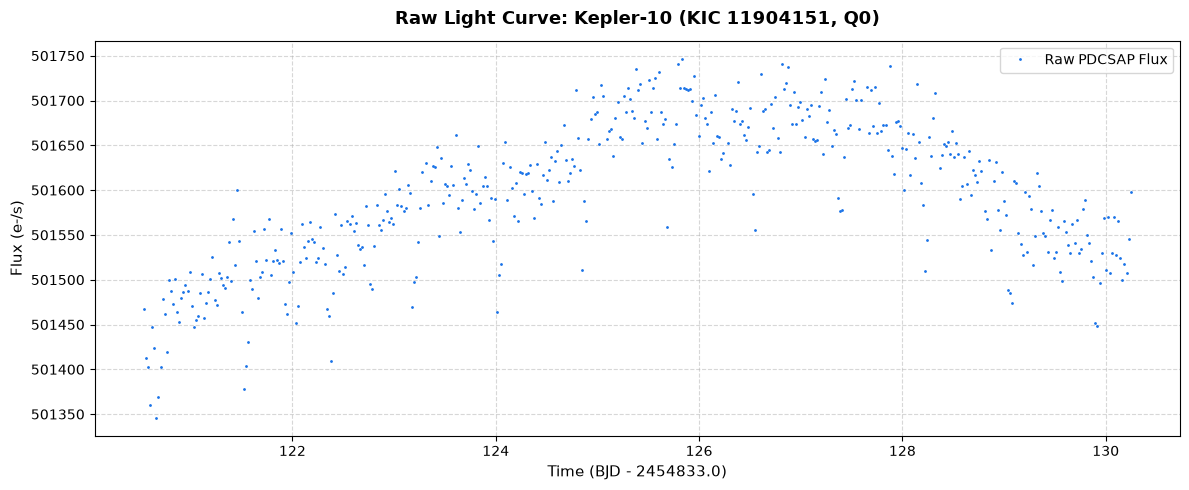


Acquiring Data:  12%|█▎        | 1/8 [00:19<02:16, 19.49s/it]

2026-06-27 12:58:44,979 [INFO] StarSight.Acquisition - Querying MAST archive for target: Kepler-22 (Quarter: first available, Cadence: Long)


2026-06-27 12:59:00,562 [INFO] StarSight.Acquisition - Downloading observations for Kepler-22...


1% (3/476) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).


2026-06-27 12:59:00,610 [INFO] lightkurve.utils - 1% (3/476) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).


2026-06-27 12:59:00,618 [INFO] StarSight.Acquisition - Successfully saved raw FITS file to: kepler-22_q0.fits


2026-06-27 12:59:00,710 [INFO] StarSight.Acquisition - Saved light curve plot to: kepler-22_q0.png


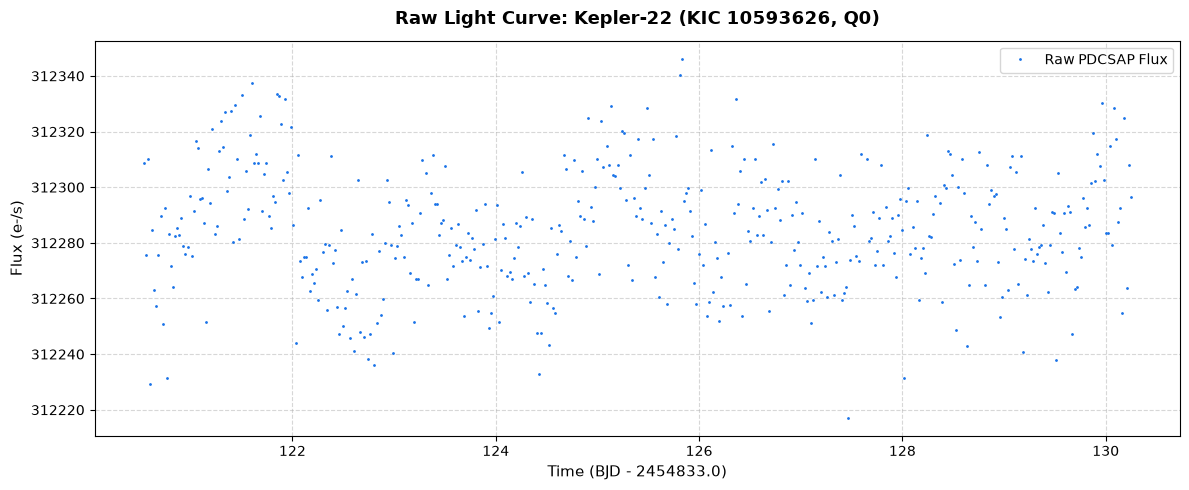


Acquiring Data:  25%|██▌       | 2/8 [00:35<01:43, 17.31s/it]

2026-06-27 12:59:00,757 [INFO] StarSight.Acquisition - Querying MAST archive for target: Kepler-90 (Quarter: first available, Cadence: Long)


2026-06-27 12:59:14,483 [INFO] StarSight.Acquisition - Downloading observations for Kepler-90...


1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).


2026-06-27 12:59:14,526 [INFO] lightkurve.utils - 1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).


2026-06-27 12:59:14,534 [INFO] StarSight.Acquisition - Successfully saved raw FITS file to: kepler-90_q1.fits


2026-06-27 12:59:14,628 [INFO] StarSight.Acquisition - Saved light curve plot to: kepler-90_q1.png


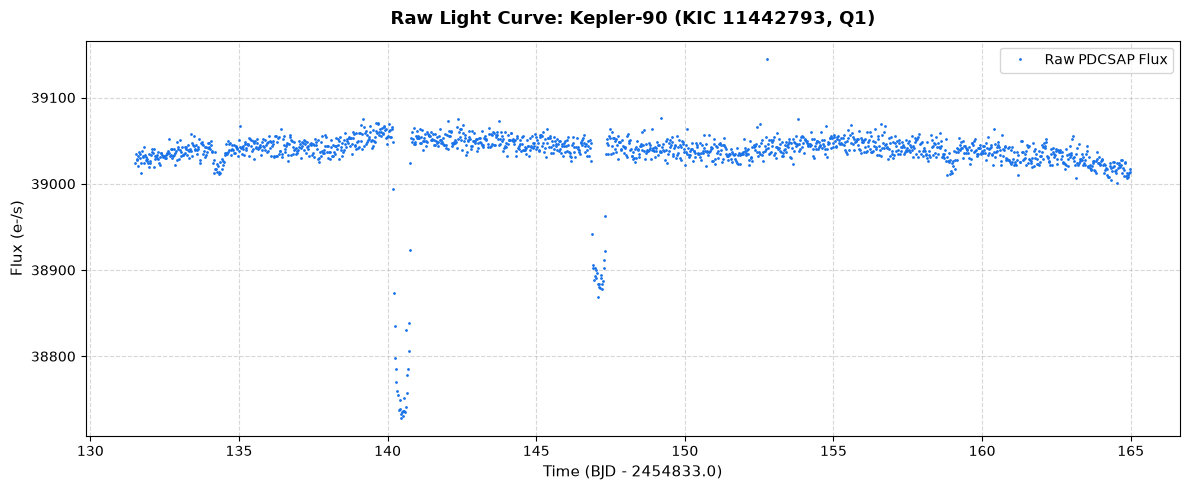


Acquiring Data:  38%|███▊      | 3/8 [00:49<01:18, 15.76s/it]

2026-06-27 12:59:14,673 [INFO] StarSight.Acquisition - Querying MAST archive for target: Kepler-186 (Quarter: first available, Cadence: Long)


2026-06-27 12:59:23,061 [INFO] StarSight.Acquisition - Downloading observations for Kepler-186...


1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).


2026-06-27 12:59:23,105 [INFO] lightkurve.utils - 1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).


2026-06-27 12:59:23,112 [INFO] StarSight.Acquisition - Successfully saved raw FITS file to: kepler-186_q1.fits


2026-06-27 12:59:23,201 [INFO] StarSight.Acquisition - Saved light curve plot to: kepler-186_q1.png


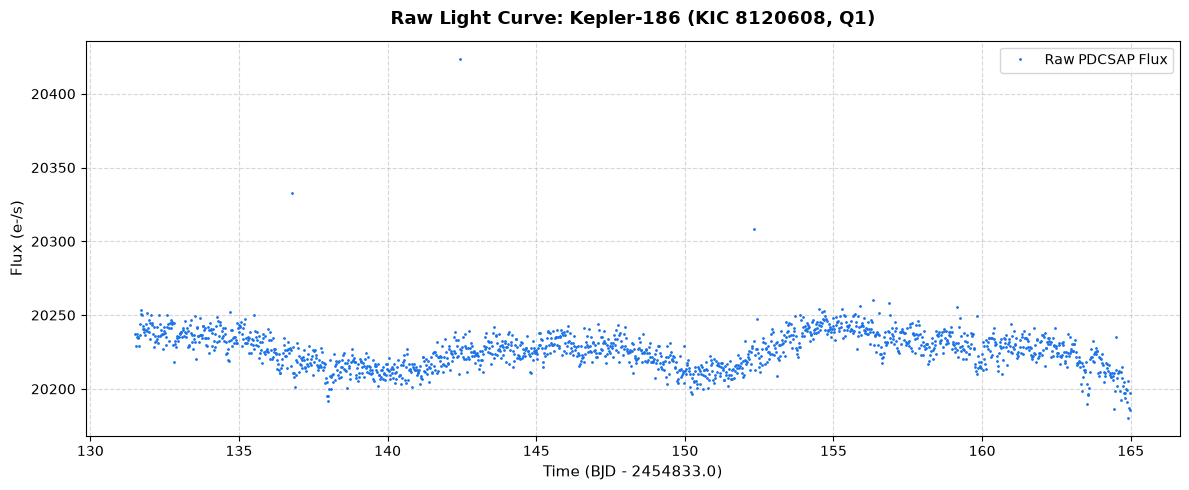


Acquiring Data:  50%|█████     | 4/8 [00:57<00:51, 12.92s/it]

2026-06-27 12:59:23,248 [INFO] StarSight.Acquisition - Querying MAST archive for target: Kepler-452 (Quarter: first available, Cadence: Long)


2026-06-27 12:59:32,720 [INFO] StarSight.Acquisition - Downloading observations for Kepler-452...


1% (3/476) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).


2026-06-27 12:59:32,764 [INFO] lightkurve.utils - 1% (3/476) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).


2026-06-27 12:59:32,769 [INFO] StarSight.Acquisition - Successfully saved raw FITS file to: kepler-452_q0.fits


2026-06-27 12:59:32,848 [INFO] StarSight.Acquisition - Saved light curve plot to: kepler-452_q0.png


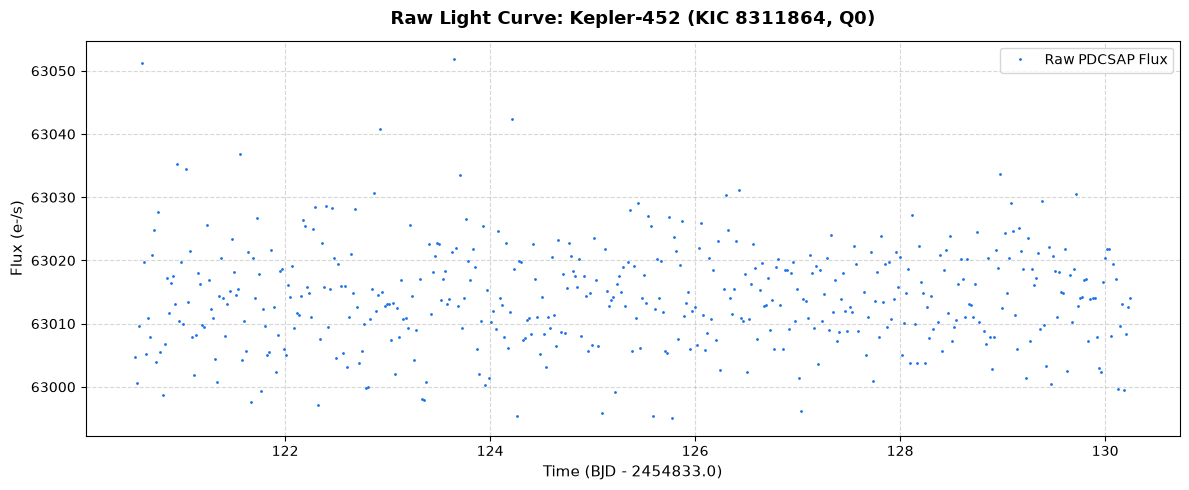


Acquiring Data:  62%|██████▎   | 5/8 [01:07<00:35, 11.74s/it]

2026-06-27 12:59:32,890 [INFO] StarSight.Acquisition - Querying MAST archive for target: Kepler-62 (Quarter: first available, Cadence: Long)


2026-06-27 12:59:44,612 [INFO] StarSight.Acquisition - Downloading observations for Kepler-62...


1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).


2026-06-27 12:59:44,658 [INFO] lightkurve.utils - 1% (13/1639) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).


2026-06-27 12:59:44,666 [INFO] StarSight.Acquisition - Successfully saved raw FITS file to: kepler-62_q1.fits


2026-06-27 12:59:44,765 [INFO] StarSight.Acquisition - Saved light curve plot to: kepler-62_q1.png


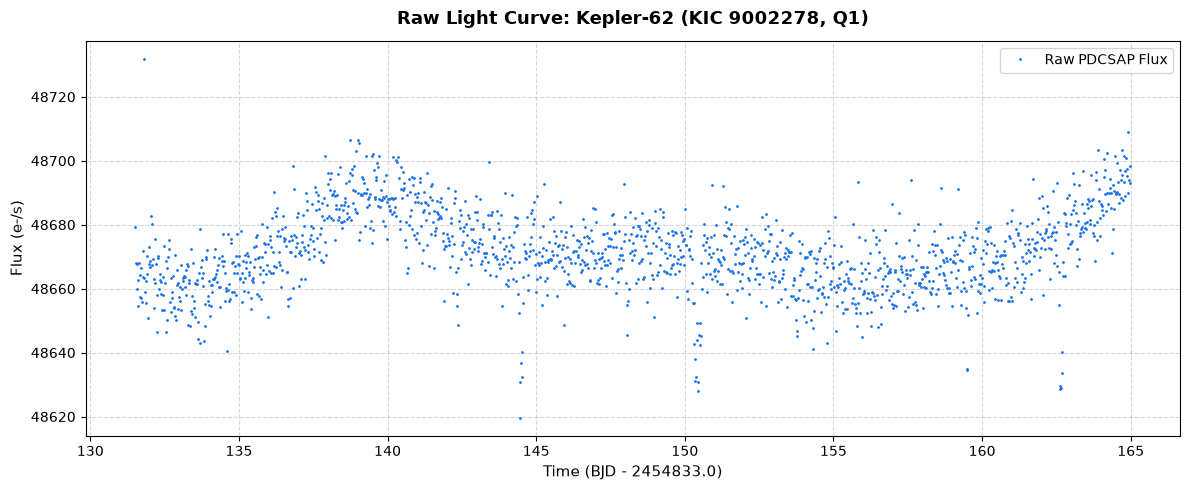


Acquiring Data:  75%|███████▌  | 6/8 [01:19<00:23, 11.82s/it]

2026-06-27 12:59:44,875 [INFO] StarSight.Acquisition - Querying MAST archive for target: Kepler-7 (Quarter: first available, Cadence: Long)


2026-06-27 12:59:56,934 [INFO] StarSight.Acquisition - Downloading observations for Kepler-7...


1% (3/476) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).


2026-06-27 12:59:56,976 [INFO] lightkurve.utils - 1% (3/476) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).


2026-06-27 12:59:56,981 [INFO] StarSight.Acquisition - Successfully saved raw FITS file to: kepler-7_q0.fits


2026-06-27 12:59:57,062 [INFO] StarSight.Acquisition - Saved light curve plot to: kepler-7_q0.png


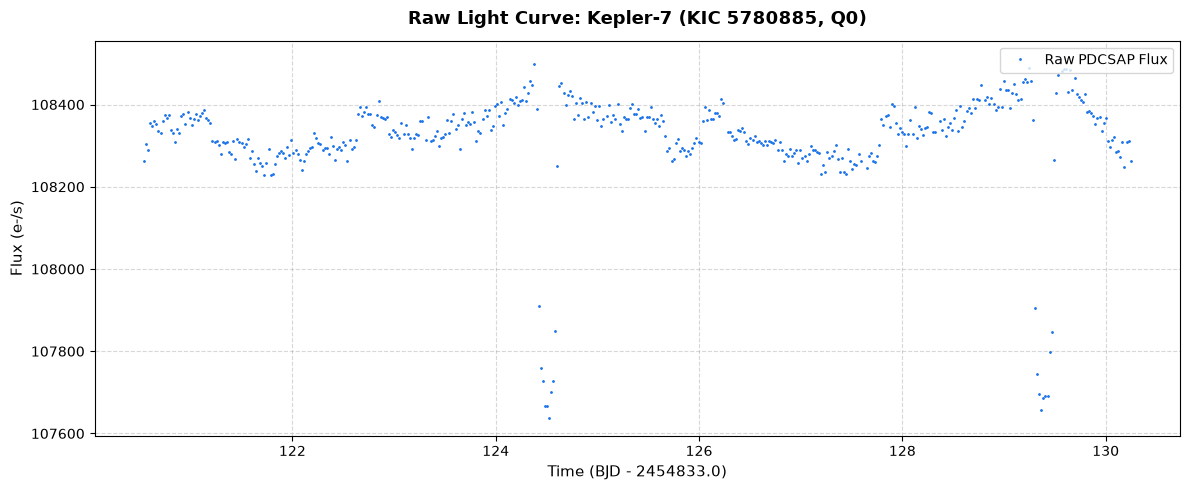


Acquiring Data:  88%|████████▊ | 7/8 [01:31<00:11, 11.96s/it]

2026-06-27 12:59:57,101 [INFO] StarSight.Acquisition - Querying MAST archive for target: Kepler-8 (Quarter: first available, Cadence: Long)


2026-06-27 13:00:14,244 [INFO] StarSight.Acquisition - Downloading observations for Kepler-8...


1% (3/476) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).


2026-06-27 13:00:14,293 [INFO] lightkurve.utils - 1% (3/476) of the cadences will be ignored due to the quality mask (quality_bitmask=1130799).


2026-06-27 13:00:14,300 [INFO] StarSight.Acquisition - Successfully saved raw FITS file to: kepler-8_q0.fits


2026-06-27 13:00:14,381 [INFO] StarSight.Acquisition - Saved light curve plot to: kepler-8_q0.png


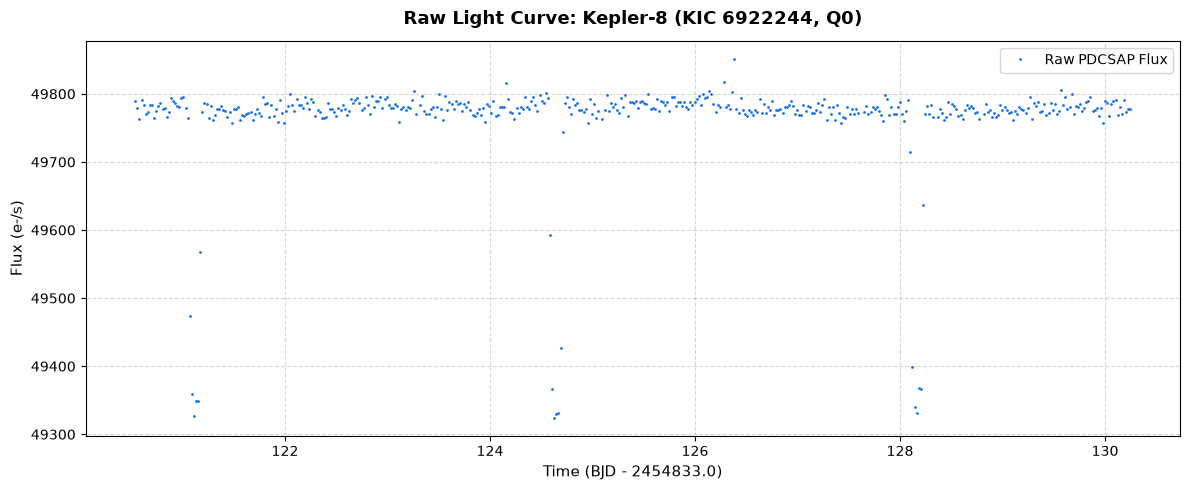


Acquiring Data: 100%|██████████| 8/8 [01:48<00:00, 13.66s/it]


Acquiring Data: 100%|██████████| 8/8 [01:48<00:00, 13.62s/it]

2026-06-27 13:00:14,440 [INFO] StarSight.Acquisition - Saved acquisition spreadsheet: /Users/suryanshdixit/Desktop/StarSight/results/download_summary.csv


In [ ]:
# Create directories
dirs = create_project_directories(PROJECT_ROOT)
raw_dir = dirs["raw"]
results_dir = dirs["results"]

# Truncate targets list to configured MAX_TARGETS bounds
targets_to_process = DEVELOPMENT_TARGETS[:MAX_TARGETS]

download_records = []
saved_files = []
successful_plots = 0

for target in tqdm(targets_to_process, desc="Acquiring Data"):
    lc = download_light_curve(target, quarter=KEPLER_QUARTER)

    record = {
        "Target": target,
        "Quarter": "N/A",
        "Cadence": "N/A",
        "Number of Observations": 0,
        "Time Span": "N/A",
        "File Name": "N/A",
        "Download Status": "Failed"
    }

    if lc is not None:
        # Extract target meta directly from the LightCurve object
        meta = extract_metadata(lc)

        actual_quarter = meta.get("Quarter", "N/A")
        fits_filename = f"{target.replace(' ', '_').lower()}_q{actual_quarter}.fits"
        fits_filepath = raw_dir / fits_filename

        # Save FITS locally
        save_fits(lc, fits_filepath)

        # Extract full metadata metrics using fits filepath as fallback reference
        meta_full = extract_metadata(lc, fits_filepath)

        # Generate plot
        plot_filename = f"{target.replace(' ', '_').lower()}_q{actual_quarter}.png"
        plot_filepath = results_dir / plot_filename
        plot_light_curve(lc, target, save_path=plot_filepath)
        successful_plots += 1

        # Update target summary records
        record["Quarter"] = actual_quarter
        record["Cadence"] = meta_full.get("Cadence", "Long")
        record["Number of Observations"] = int(meta_full.get("Number of observations", 0))
        record["Time Span"] = meta_full.get("Time span", "N/A")
        record["File Name"] = fits_filename
        record["Download Status"] = "Success"

        saved_files.append(fits_filepath)

    download_records.append(record)

# Export download summary to CSV file
df_summary = pd.DataFrame(download_records)
csv_filepath = results_dir / "download_summary.csv"
df_summary.to_csv(csv_filepath, index=False)
logger.info(f"Saved acquisition spreadsheet: {csv_filepath.resolve()}")

### **8. Notebook Validation**
Print a validation checklist summary to confirm pipeline execution success.

In [ ]:
print("="*50)
print("          STAR SIGHT DATA ACQUISITION REPORT")
print("="*50)

requested_targets = len(targets_to_process)
successful_downloads = sum(1 for r in download_records if r["Download Status"] == "Success")
failed_downloads = requested_targets - successful_downloads

print(f"Requested Targets              : {requested_targets} ({', '.join(targets_to_process)})")
print(f"Successful Downloads           : {successful_downloads}")
print(f"Failed Downloads               : {failed_downloads}")
print(f"FITS Files Saved               : {len(saved_files)}")
print(f"Metadata Successfully Extracted : {successful_downloads}")
print(f"Plots Generated                : {successful_plots}")
print(f"Summary CSV Exported           : {'Yes' if csv_filepath.exists() else 'No'}")
print("="*50)

          STAR SIGHT DATA ACQUISITION REPORT
Requested Targets              : 8 (Kepler-10, Kepler-22, Kepler-90, Kepler-186, Kepler-452, Kepler-62, Kepler-7, Kepler-8)
Successful Downloads           : 8
Failed Downloads               : 0
FITS Files Saved               : 8
Metadata Successfully Extracted : 8
Plots Generated                : 8
Summary CSV Exported           : Yes


### **9. Results Summary**

### Data Analysis Key Findings
- Configured project folders (`data/raw/`, `data/processed/`, and `results/`) relative to the root directory.
- Acquired long-cadence observation data for target stars from the MAST archive.
- Extracted observation metadata (Kepler ID, Mission, Quarter, Cadence, Number of observations, Time span) directly from the download interface.
- Plotted raw light curves showing uncorrected flux variations over the time interval.
- Generated `results/download_summary.csv` summarizing dataset metrics.

### Insights or Next Steps
- The downloaded raw light curves show long-term systematic trends, gaps, and outliers.
- The next step is Milestone 2: Preprocessing and Cleaning (outlier removal, sigma clipping, normalization, and detrending).